Analyse Code        

In [3]:
import pandas as pd

# Load the data
df = pd.read_csv('PPR.csv', encoding='latin-1')

# Show first 5 rows
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

  Date of Sale (dd/mm/yyyy)                                         Address  \
0                01/01/2010          5 Braemor Drive, Churchtown, Co.Dublin   
1                03/01/2010  134 Ashewood Walk, Summerhill Lane, Portlaoise   
2                04/01/2010             1 Meadow Avenue, Dundrum, Dublin 14   
3                04/01/2010                         1 The Haven, Mornington   
4                04/01/2010                   11 Melville Heights, Kilkenny   

     County Eircode    Price () Not Full Market Price VAT Exclusive  \
0    Dublin     NaN  343,000.00                    No            No   
1     Laois     NaN  185,000.00                    No           Yes   
2    Dublin     NaN  438,500.00                    No            No   
3     Meath     NaN  400,000.00                    No            No   
4  Kilkenny     NaN  160,000.00                    No            No   

                 Description of Property  \
0  Second-Hand Dwelling house /Apartment   
1   

C:\Users\Liam\AppData\Local\Temp\ipykernel_11164\1432960179.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('PPR.csv', encoding='latin-1')


In [4]:
# Clean the data
df.columns = ['date', 'address', 'county', 'eircode', 'price', 'not_full_market', 'vat_exclusive', 'property_type', 'size']

# Fix date column
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Fix price column - remove any currency symbols and commas
df['price'] = df['price'].astype(str)
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Remove nulls and outliers
df = df.dropna(subset=['price', 'county'])
df = df[df['price'] > 10000]
df = df[df['price'] < 5000000]

print("Cleaned data shape:", df.shape)
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("\nCounties:", df['county'].nunique())
print(df['county'].value_counts().head(10))

Cleaned data shape: (785343, 11)

Date range: 2010-01-01 00:00:00 to 2026-05-29 00:00:00

Counties: 26
county
Dublin       245453
Cork          87031
Kildare       42763
Galway        37989
Meath         32751
Limerick      28812
Wexford       27496
Wicklow       26582
Louth         21982
Waterford     21546
Name: count, dtype: int64


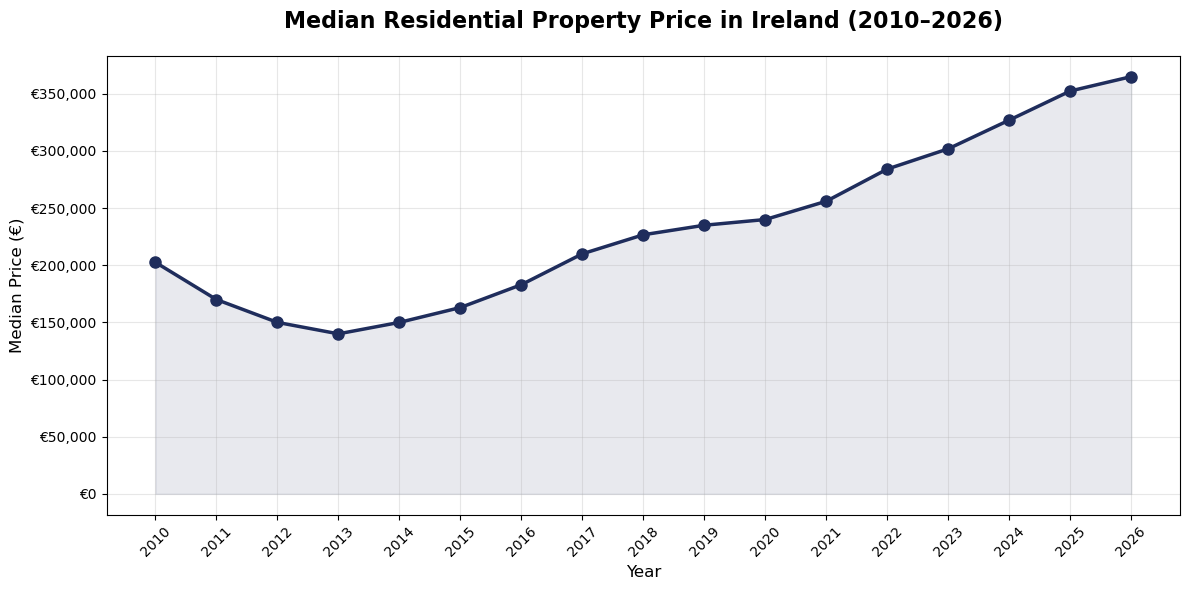

Chart saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Average price by year
yearly_avg = df.groupby('year')['price'].median().reset_index()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_avg['year'], yearly_avg['price'], marker='o', linewidth=2.5, color='#1F2D5C', markersize=8)
ax.fill_between(yearly_avg['year'], yearly_avg['price'], alpha=0.1, color='#1F2D5C')

ax.set_title('Median Residential Property Price in Ireland (2010–2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Price (€)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.grid(True, alpha=0.3)
ax.set_xticks(yearly_avg['year'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('price_trend_ireland.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

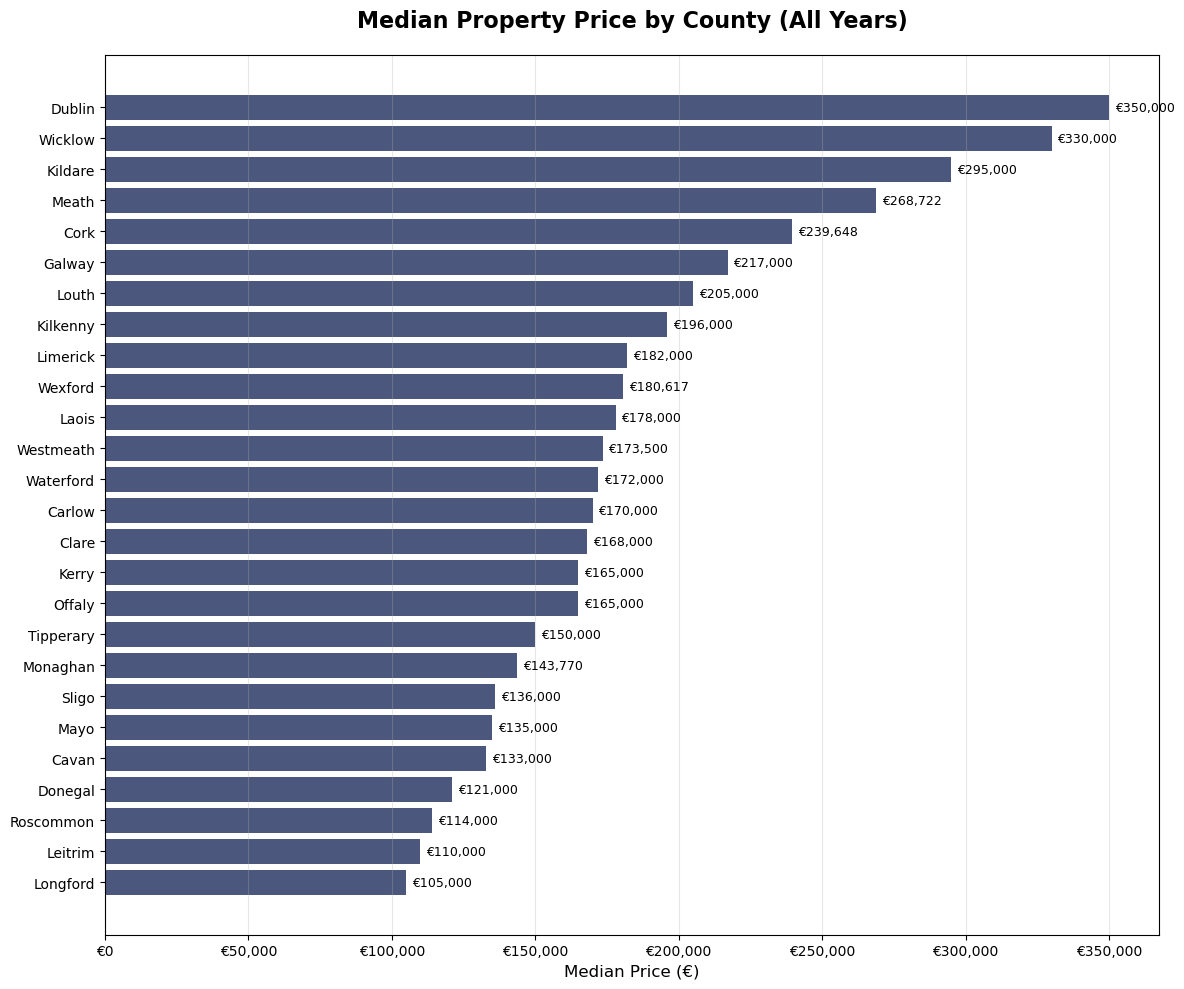

Chart saved!


In [6]:
# Average price by county
county_avg = df.groupby('county')['price'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(county_avg.index, county_avg.values, color='#1F2D5C', alpha=0.8)

ax.set_title('Median Property Price by County (All Years)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Median Price (€)', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for bar, val in zip(bars, county_avg.values):
    ax.text(val + 2000, bar.get_y() + bar.get_height()/2, 
            f'€{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('price_by_county.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

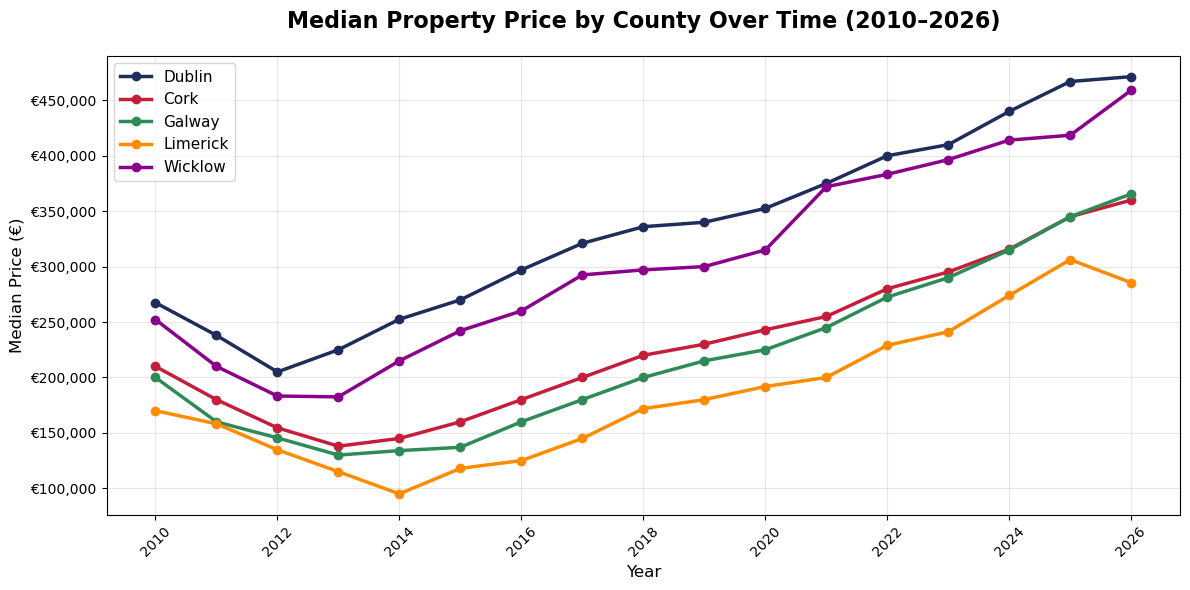

Chart saved!


In [14]:
# Price trends for key counties over time
counties_to_plot = ['Dublin', 'Cork', 'Galway', 'Limerick', 'Wicklow']

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1F2D5C', '#C41E3A', '#2E8B57', '#FF8C00', '#8B008B']

for county, color in zip(counties_to_plot, colors):
    county_data = df[df['county'] == county].groupby('year')['price'].median()
    ax.plot(county_data.index, county_data.values, marker='o', 
            linewidth=2.5, label=county, color=color, markersize=6)

ax.set_title('Median Property Price by County Over Time (2010–2026)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Price (€)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('price_trend_by_county.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

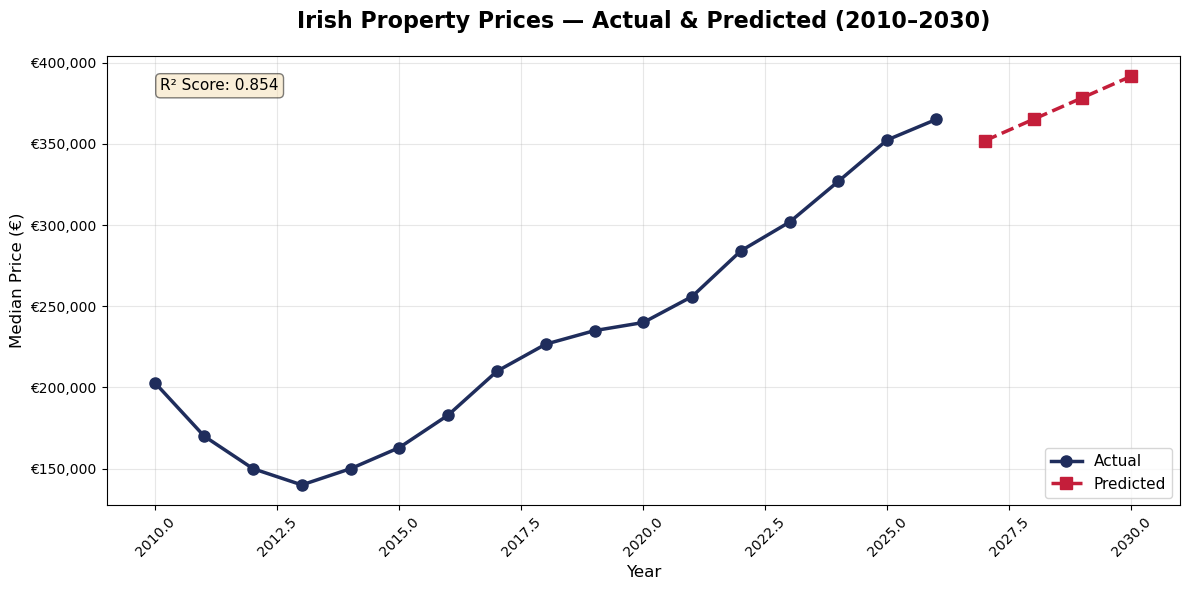


R² Score: 0.854
2027: €351,914
2028: €365,155
2029: €378,396
2030: €391,637


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Predict future prices for Ireland overall
yearly_avg = df.groupby('year')['price'].median().reset_index()

X = yearly_avg['year'].values.reshape(-1, 1)
y = yearly_avg['price'].values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict 2026-2030
future_years = np.array([2027, 2028, 2029, 2030]).reshape(-1, 1)
predictions = model.predict(future_years)

# Plot actual + predicted
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_avg['year'], yearly_avg['price'], marker='o', 
        linewidth=2.5, color='#1F2D5C', label='Actual', markersize=8)
ax.plot(future_years, predictions, marker='s', linewidth=2.5, 
        color='#C41E3A', linestyle='--', label='Predicted', markersize=8)

ax.set_title('Irish Property Prices — Actual & Predicted (2010–2030)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Price (€)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

r2 = r2_score(y, model.predict(X))
ax.text(0.05, 0.95, f'R² Score: {r2:.3f}', transform=ax.transAxes, 
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('price_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nR² Score: {r2:.3f}")
for year, pred in zip([2027, 2028, 2029, 2030], predictions):
    print(f"{year}: €{pred:,.0f}")

In [12]:
# Save a summary
print("=== IRISH PROPERTY PRICE ANALYSIS - SUMMARY ===")
print(f"Total transactions analysed: {len(df):,}")
print(f"Date range: 2010 - 2026")
print(f"Most expensive county: Dublin (€{df[df['county']=='Dublin']['price'].median():,.0f})")
print(f"Most affordable county: Leitrim (€{df[df['county']=='Leitrim']['price'].median():,.0f})")
print(f"National median 2010: €{df[df['year']==2010]['price'].median():,.0f}")
print(f"National median 2026: €{df[df['year']==2026]['price'].median():,.0f}")
print(f"Price increase since crash low (2013): {((df[df['year']==2026]['price'].median() / df[df['year']==2013]['price'].median()) - 1) * 100:.1f}%")

=== IRISH PROPERTY PRICE ANALYSIS - SUMMARY ===
Total transactions analysed: 785,343
Date range: 2010 - 2026
Most expensive county: Dublin (€350,000)
Most affordable county: Leitrim (€110,000)
National median 2010: €202,550
National median 2026: €365,000
Price increase since crash low (2013): 160.7%
